# Simulation of a Serial Batch Reactor Network

The purpose of this tutorial is to implement and simulate a serial batch chemical reactor network using the libraries `pymcpp` (MC++) and `cronos` (CRONOS).

The network consists of two batch reactors connected in series. The reaction mechanism characterizing the two reactors is the same:
$$\begin{equation*}
    2{\sf A} \xrightarrow{k_1} {\sf B} \xrightarrow{k_2} {\sf C}
\end{equation*}$$
where component ${\sf B}$ is the desired product.

The reactor dynamics are ordinary differential equations (ODEs) that describe the evolution of component molar concentrations in continuous time:
$$\begin{align*}
        \dot{c}_{{\sf A},j}(t) &= -2k_{1,j}(T_j)\,c_{{\sf A},j}(t)^2\\
        \dot{c}_{{\sf B},j}(t) &= k_{1,j}(T_j)\,c_{{\sf A},j}(t)^2 - k_{2,j}(T_j)\,c_{{\sf B},j}(t)\\
        \dot{c}_{{\sf C},j}(t) &= k_{2,j}(T_j)\,c_{{\sf B},j}(t)
\end{align*}$$
where $c_{i,j}(t)$ ($\text{kmol m}^{-3}$) describes the molar concentration of component $i={\sf A},{\sf B},{\sf C}$ in reactor $j=1,2$; and $T_j$ (K) the temperature in reactor $j$.

The system adheres to Arrhenius kinetics:
$$\begin{equation*}
    k_{r,j}(T) = k^\circ_{r,j} \exp\left(-\frac{E_{r,j}}{RT}\right)
\end{equation*}$$
where $T$ (K) is the reaction temperature; $k_{r,j}$ the temperature-dependent rate constant of reaction step $r=1,2$ for reactor $j$; $k^\circ_{r,j}$ the pre-exponential factor; $E_{r,j}$ the activation energy; and $R$ denotes the ideal gas constant.

The time is normalized by the batch duration $\tau_j$, $t \in [0,1]$, so that $\tau_j$ appears as a parameter of the dynamics.

We start by importing both the `pymcpp` and `cronos` libraries. Set `CRONOS_PYPATH` (or edit the cell) if the modules are not on the Python path.

In [1]:
import pymcpp
import cronos
from pymcpp import FFGraph, FFPartial, FFEval
from cronos import FFDom, FFModel, ODESLV, FFODESLV

## A single batch reactor

The model is declared on a DAG: the independent variable $t$, the states, the parameters (batch duration, temperature and initial concentrations) and the constants (kinetic parameters). The derivatives and point evaluations along $t$ are DAG operations: `FFPartial` and `FFEval`.

In [2]:
IVPDAG = FFGraph()

# Independent variable (normalized time)
t = IVPDAG.add_var("t")

# States
cA = IVPDAG.add_var("cA")
cB = IVPDAG.add_var("cB")
cC = IVPDAG.add_var("cC")

# Parameters
tau = IVPDAG.add_var("tau")
T   = IVPDAG.add_var("T")
cA0 = IVPDAG.add_var("cA0")
cB0 = IVPDAG.add_var("cB0")
cC0 = IVPDAG.add_var("cC0")

# Constants
kr1 = IVPDAG.add_var("kr1")
Ea1 = IVPDAG.add_var("Ea1")
kr2 = IVPDAG.add_var("kr2")
Ea2 = IVPDAG.add_var("Ea2")

OpP, OpE = FFPartial(), FFEval()

A solver `ODESLV` is created and populated with the parametric initial value problem, through the `FFModel` interface: the time domain, the states, the inputs (parameters) and constants, the equations with their region and role, and the outputs:

In [3]:
IVP = ODESLV(IVPDAG)
IVP.add_domain(t, FFDom(0., 1., 1))    # normalized time horizon, one stage
IVP.set_evolution_domain(t)
IVP.add_state(cA, [t])
IVP.add_state(cB, [t])
IVP.add_state(cC, [t])
for p in (tau, T, cA0, cB0, cC0):
    IVP.add_input(p)
IVP.set_constant([kr1, Ea1, kr2, Ea2])

R = 8.314  # J/mol·K
k1 = kr1 * pymcpp.exp(-Ea1 / (R * T))
k2 = kr2 * pymcpp.exp(-Ea2 / (R * T))

INTERIOR = FFModel.EqnOptions(FFModel.EqnRole.INTERIOR)
INITIAL  = FFModel.EqnOptions(FFModel.EqnRole.INITIAL)
T_INT = FFDom.ALL - FFDom.LB           # (0,1]: the dynamics
IVP.add_equation(OpP(cA, t) - tau * (-2 * k1 * cA**2),         [t], [T_INT], INTERIOR)
IVP.add_equation(OpP(cB, t) - tau * (k1 * cA**2 - k2 * cB),    [t], [T_INT], INTERIOR)
IVP.add_equation(OpP(cC, t) - tau * (k2 * cB),                 [t], [T_INT], INTERIOR)
IVP.add_equation([cA - cA0, cB - cB0, cC - cC0], [t], [FFDom.LB], INITIAL)   # t = 0: initial values

for c in (cA, cB, cC):                 # batch-end concentrations
    IVP.add_output(OpE(c, t, 1.))

IVP.setup()
IVP.report()


FFModel ** the WORKING model (after setup)

DOMAINS (1)
  t              [0 : 1]  elements=1 nodes/element=4   <= EVOLUTION (set)

STATES (3)
  cA                   on t
  cB                   on t
  cC                   on t

INPUTS (5)
  tau                  on -
  T                    on -
  cA0                  on -
  cB0                  on -
  cC0                  on -

CONSTANTS (4)
  kr1                 
  Ea1                 
  kr2                 
  Ea2                 

EQUATIONS (6)
  INTERIOR   block=0   0 = Partial[t]( cA ) - tau * ( ( kr1 * EXP( ( - Ea1 ) / ( T * 8.314 ) ) ) * (-2) ) * SQR( cA )   on t in (0, 1]
  INTERIOR   block=0   0 = Partial[t]( cB ) - tau * ( ( kr1 * EXP( ( - Ea1 ) / ( T * 8.314 ) ) ) * SQR( cA ) - cB * kr2 * EXP( ( - Ea2 ) / ( T * 8.314 ) ) )   on t in (0, 1]
  INTERIOR   block=0   0 = Partial[t]( cC ) - tau * cB * kr2 * EXP( ( - Ea2 ) / ( T * 8.314 ) )   on t in (0, 1]
  INITIAL    block=0   0 = cA - cA0   on t = 0
  INITIAL    block=0   0 = cB 

The model report shows the declared model as the solver sees it: the equations written out with their regions, the outputs, the classification and the degrees of freedom.

A simulation of the first reactor for a batch duration $\tau=600~\rm min$ and temperature $T=750~\rm K$, starting from $c_{\sf A}=2~\text{kmol m}^{-3}$. The inputs and constants are given **by name**; the forward (`solve_fsens`) and adjoint (`solve_asens`) sensitivity analyses give the gradients of the batch-end concentrations with respect to the parameters:

In [4]:
values = {tau: [600.], T: [750.], cA0: [2.], cB0: [0.], cC0: [0.],
          kr1: [6.66e-3], Ea1: [2.52e3], kr2: [1.03], Ea2: [5e3]}

IVP.options.DISPLAY = 1      # displays numerical integration results
IVP.options.RESRECORD = 200  # record 200 points along time horizon

IVP.solve(values)
IVP.solve_fsens(values)
IVP.solve_asens(values)

 @t = 0.000000e+00 :


  x[0] = 2.000000e+00


  x[1] = 0.000000e+00


  x[2] = 0.000000e+00


 @t = 1.000000e+00 :


...

  fp[4][2] = 1.000000e+00


 No STEPS    386


 No EVALATIONS   RHS: 568   JAC: 0


 CPU TIME (SEC)     0.03316


<STATUS.NORMAL: 0>

The options of `ODESLV` combine the model options (`FFModel.Options`) and the CVODES options; each is documented (e.g. `help(ODESLV.Options.RTOL)`, or `help(IVP.options)` for all of them):

In [5]:
for name in ("INTMETH", "NLINSOL", "LINSOL", "RTOL", "ATOL", "NMAX", "RESRECORD", "DISPLAY"):
    print("%-10s = %-24s %s" % (name, getattr(IVP.options, name), getattr(ODESLV.Options, name).__doc__.split(".")[0]))

INTMETH    = INTEGRATION_METHOD.MSBDF Numerical integration method [Default: MSBDF]
NLINSOL    = NONLINEAR_SOLVER.NEWTON  Nonlinear solver method [Default: NEWTON]
LINSOL     = LINEAR_SOLVER.DIAG       Linear solver method and Jacobian approximation [Default: DIAG]
RTOL       = 1e-07                    Relative (scalar) integration tolerance
ATOL       = 1e-09                    Absolute (scalar) integration tolerance
NMAX       = 2000                     Maximum number of steps in a time stage [Default: 0 (2000)]
RESRECORD  = 200                      Whether or not to record results (default: 0)
DISPLAY    = 1                        Display level (default: 1)


The gradients of the batch-end concentrations, one row per parameter and one column per output, agree between forward and adjoint sensitivity analysis:

In [6]:
import numpy as np
import matplotlib.pyplot as plt

IVP.options.DISPLAY = 0

IVP.solve_fsens(values)
G_fwd = np.array(IVP.val_function_gradient())

IVP.solve_asens(values)
G_adj = np.array(IVP.val_function_gradient())

names = [str(p) for p in IVP.var_parameter]
print("%-5s %14s %14s %14s" % ("", "d cA(1)", "d cB(1)", "d cC(1)"))
for n, row in zip(names, G_fwd):
    print("%-5s %14.6e %14.6e %14.6e" % ((n,) + tuple(row)))
print("max |forward - adjoint| =", np.abs(G_fwd - G_adj).max())

             d cA(1)        d cB(1)        d cC(1)
tau    -2.611537e-04  -8.701202e-07   1.314472e-04
T      -8.443363e-05  -4.332230e-07   4.265013e-05
cA0     7.342559e-03   2.446417e-05   4.963046e-01
cB0     0.000000e+00  -1.723271e-14   1.000000e+00
cC0     0.000000e+00   0.000000e+00   1.000000e+00
max |forward - adjoint| = 3.4140452764841456e-07


### Trajectories

The trajectories are displayed from the `results_solve` field: NumPy arrays of the recorded time points `t`, states `x` (in the order of `var_state`) and quadratures `q`. The normalized time is scaled back by $\tau$:

t: (201,) | x: (201, 3)


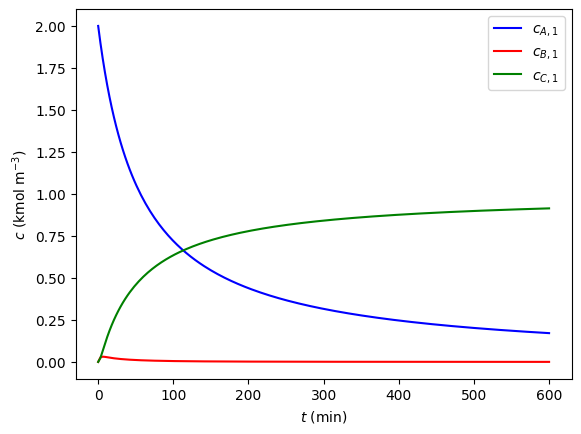

In [7]:
IVP.solve(values)

TAU = values[tau][0]
res = IVP.results_solve
print("t:", res.t.shape, "| x:", res.x.shape)
#print( res.x )

plt.xlabel('$t$ (min)')
plt.ylabel('$c$ (kmol m$^{-3}$)')
plt.plot(res.t * TAU, res.x[:, 0], "-b", label="$c_{A,1}$")
plt.plot(res.t * TAU, res.x[:, 1], "-r", label="$c_{B,1}$")
plt.plot(res.t * TAU, res.x[:, 2], "-g", label="$c_{C,1}$")
plt.legend(loc="best")
plt.show()

The sensitivity trajectories of `solve_fsens` are in `results_fsens`: `xp[i]` holds the sensitivities of the states with respect to the $i$-th sensitivity direction (here the parameters, in the order of `var_parameter`). The sensitivities of the concentrations with respect to the temperature $T$:

xp: (5, 201, 3) (directions, points, states)


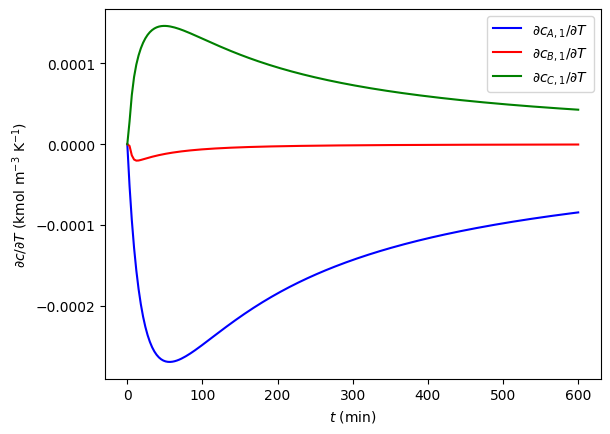

In [8]:
IVP.solve_fsens(values)
sens = IVP.results_fsens
iT = names.index("T")
print("xp:", sens.xp.shape, "(directions, points, states)")

plt.xlabel('$t$ (min)')
plt.ylabel(r'$\partial c / \partial T$ (kmol m$^{-3}$ K$^{-1}$)')
plt.plot(sens.t * TAU, sens.xp[iT, :, 0], "-b", label=r"$\partial c_{A,1}/\partial T$")
plt.plot(sens.t * TAU, sens.xp[iT, :, 1], "-r", label=r"$\partial c_{B,1}/\partial T$")
plt.plot(sens.t * TAU, sens.xp[iT, :, 2], "-g", label=r"$\partial c_{C,1}/\partial T$")
plt.legend(loc="best")
plt.show()

l: (3, 202, 3) (directions, points, states)


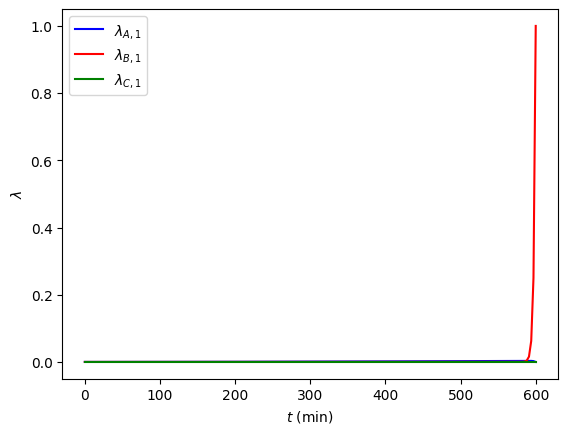

In [9]:
IVP.solve_asens(values)
adj = IVP.results_asens
iF = 2 # Output cC(1)
print("l:", adj.l.shape, "(directions, points, states)")

plt.xlabel('$t$ (min)')
plt.ylabel(r'$\lambda$')
plt.plot(adj.t * TAU, adj.l[iT, :, 0], "-b", label=r"$\lambda_{A,1}$")
plt.plot(adj.t * TAU, adj.l[iT, :, 1], "-r", label=r"$\lambda_{B,1}$")
plt.plot(adj.t * TAU, adj.l[iT, :, 2], "-g", label=r"$\lambda_{C,1}$")
plt.legend(loc="best")
plt.show()

### Both reactors in series

The second reactor starts from the batch-end concentrations of ${\sf A}$ and ${\sf B}$ in the first one, without ${\sf C}$ (separated between the reactors). Two successive simulations with the same solver give the trajectories through the network, here for $\tau_1=\tau_2=400~\rm min$ and $T_1=T_2=800~\rm K$:

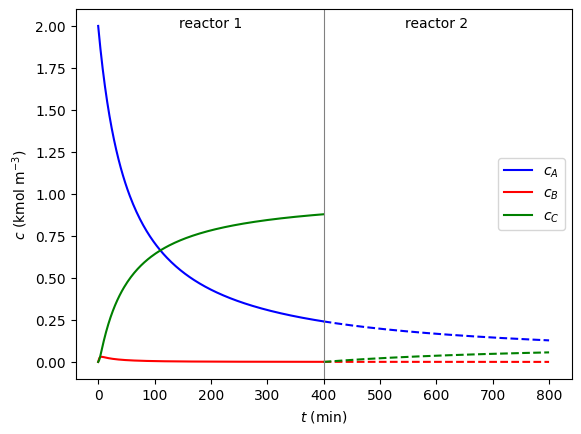

In [10]:
kin = {kr1: [6.66e-3], Ea1: [2.52e3], kr2: [1.03], Ea2: [5e3]}
TAU1, T1v, TAU2, T2v = 400., 800., 400., 800.

IVP.solve({tau: [TAU1], T: [T1v], cA0: [2.], cB0: [0.], cC0: [0.], **kin})
r1 = IVP.results_solve                  # NumPy arrays: copies, kept after the next solve
cA1f, cB1f, cC1f = IVP.val_function()

IVP.solve({tau: [TAU2], T: [T2v], cA0: [cA1f], cB0: [cB1f], cC0: [0.], **kin})
r2 = IVP.results_solve
traj1 = np.column_stack([r1.t * TAU1, r1.x])
traj2 = np.column_stack([TAU1 + r2.t * TAU2, r2.x])

plt.xlabel('$t$ (min)')
plt.ylabel('$c$ (kmol m$^{-3}$)')
for k, (col, lab) in enumerate((("b", "A"), ("r", "B"), ("g", "C")), start=1):
    plt.plot(traj1[:, 0], traj1[:, k], "-" + col, label="$c_{%s}$" % lab)
    plt.plot(traj2[:, 0], traj2[:, k], "--" + col)
plt.axvline(TAU1, color="grey", lw=0.8)
plt.text(TAU1 / 2, plt.ylim()[1] * 0.95, "reactor 1", ha="center")
plt.text(TAU1 + TAU2 / 2, plt.ylim()[1] * 0.95, "reactor 2", ha="center")
plt.legend(loc="center right")
plt.show()

## The reactor network as a DAG

To simulate the two batch reactors connected in series as one function, we define a separate DAG and embed the solver twice as an external operation `FFODESLV`. Each embedding maps the solver's inputs to DAG variables: map 1 lists the inputs differentiated through the solver's sensitivities, map 2 the remaining ones (here the constants), whose values pass through the DAG:

In [11]:
DAG = FFGraph()
OpIVP = FFODESLV()
IVP.options.DISPLAY = 0    # turn off display during numerical simulation
IVP.options.RESRECORD = 0  # turn off trajectory record

In [12]:
# reactor #1 initial concentrations
cA1_0 = DAG.add_var("cA1_0")
cB1_0 = DAG.add_var("cB1_0")
cC1_0 = DAG.add_var("cC1_0")

# reactor #1 parameters
tau1 = DAG.add_var("tau1")
T1   = DAG.add_var("T1")

# reactor #1 constants
kr11 = DAG.add_var("kr11")
Ea11 = DAG.add_var("Ea11")
kr21 = DAG.add_var("kr21")
Ea21 = DAG.add_var("Ea21")

[cA1_f, cB1_f, cC1_f] = OpIVP({tau: [tau1], T: [T1], cA0: [cA1_0], cB0: [cB1_0], cC0: [cC1_0]},
                              {kr1: [kr11], Ea1: [Ea11], kr2: [kr21], Ea2: [Ea21]}, IVP)

cA1_f.set("cA1_f")
cB1_f.set("cB1_f")
cC1_f.set("cC1_f")
DAG.output([cA1_f, cB1_f, cC1_f])

print(cA1_f, " = ", cA1_f.str())


OPERATIONS IN SUBGRAPH:
  tau1	<<  VARIABLE
  T1	<<  VARIABLE
  cA1_0	<<  VARIABLE
  cB1_0	<<  VARIABLE
  cC1_0	<<  VARIABLE
  kr11	<<  VARIABLE
  Ea11	<<  VARIABLE
  kr21	<<  VARIABLE
  Ea21	<<  VARIABLE
  cA1_f	<<  ODE[0x1dbc6f30]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )	[0]
  cB1_f	<<  ODE[0x1dbc6f30]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )	[1]
  cC1_f	<<  ODE[0x1dbc6f30]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )	[2]
DEPENDENTS IN SUBGRAPH:
  0:  cA1_f
  1:  cB1_f
  2:  cC1_f
WORK ARRAY SIZE: 21
MOVE ARRAY SIZE: 9
cA1_f  =  ODE[0x1dbc6f30][0]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )


In [13]:
# reactor #2 initial concentrations
cC2_0 = DAG.add_var("cC2_0")

# reactor #2 parameters
tau2 = DAG.add_var("tau2")
T2   = DAG.add_var("T2")

# reactor #2 constants
kr12 = DAG.add_var("kr12")
Ea12 = DAG.add_var("Ea12")
kr22 = DAG.add_var("kr22")
Ea22 = DAG.add_var("Ea22")

[cA2_f, cB2_f, cC2_f] = OpIVP({tau: [tau2], T: [T2], cA0: [cA1_f], cB0: [cB1_f], cC0: [cC2_0]},
                              {kr1: [kr12], Ea1: [Ea12], kr2: [kr22], Ea2: [Ea22]}, IVP)

cA2_f.set("cA2_f")
cB2_f.set("cB2_f")
cC2_f.set("cC2_f")
DAG.output([cA2_f, cB2_f, cC2_f])


OPERATIONS IN SUBGRAPH:
  tau2	<<  VARIABLE
  T2	<<  VARIABLE
  tau1	<<  VARIABLE
  T1	<<  VARIABLE
  cA1_0	<<  VARIABLE
  cB1_0	<<  VARIABLE
  cC1_0	<<  VARIABLE
  kr11	<<  VARIABLE
  Ea11	<<  VARIABLE
  kr21	<<  VARIABLE
  Ea21	<<  VARIABLE
  cA1_f	<<  ODE[0x1dbc6f30]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )	[0]
  cB1_f	<<  ODE[0x1dbc6f30]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )	[1]
  cC1_f	<<  ODE[0x1dbc6f30]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 )	[2]
  cC2_0	<<  VARIABLE
  kr12	<<  VARIABLE
  Ea12	<<  VARIABLE
  kr22	<<  VARIABLE
  Ea22	<<  VARIABLE
  cA2_f	<<  ODE[0x1dbfa160]( tau2, T2, cA1_f, cB1_f, cC2_0, kr12, Ea12, kr22, Ea22 )	[0]
  cB2_f	<<  ODE[0x1dbfa160]( tau2, T2, cA1_f, cB1_f, cC2_0, kr12, Ea12, kr22, Ea22 )	[1]
  cC2_f	<<  ODE[0x1dbfa160]( tau2, T2, cA1_f, cB1_f, cC2_0, kr12, Ea12, kr22, Ea22 )	[2]
DEPENDENTS IN SUBGRAPH:
  0:  cA2_f
  1:  cB2_f
  2:  cC2_f
WORK ARRAY SIZE: 31
MOVE ARRAY SIZE: 9


Lastly, we define the two process outputs of interest:

In [14]:
xC1_f = cC1_f / (cA1_f + cB1_f + cC1_f)
xC1_f.set("xC1_f")

print(xC1_f, " = ", xC1_f.str())

xC1_f  =  ODE[0x1dbc6f30][2]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ) / ( ODE[0x1dbc6f30][2]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ) + ODE[0x1dbc6f30][0]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ) + ODE[0x1dbc6f30][1]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ) )


In [15]:
xB2_f = cB2_f / (cA2_f + cB2_f + cC2_f)
xB2_f.set("xB2_f")

print(xB2_f, " = ", xB2_f.str())

xB2_f  =  ODE[0x1dbfa160][1]( tau2, T2, ODE[0x1dbc6f30][0]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), ODE[0x1dbc6f30][1]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), cC2_0, kr12, Ea12, kr22, Ea22 ) / ( ODE[0x1dbfa160][2]( tau2, T2, ODE[0x1dbc6f30][0]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), ODE[0x1dbc6f30][1]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), cC2_0, kr12, Ea12, kr22, Ea22 ) + ODE[0x1dbfa160][0]( tau2, T2, ODE[0x1dbc6f30][0]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), ODE[0x1dbc6f30][1]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), cC2_0, kr12, Ea12, kr22, Ea22 ) + ODE[0x1dbfa160][1]( tau2, T2, ODE[0x1dbc6f30][0]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), ODE[0x1dbc6f30][1]( tau1, T1, cA1_0, cB1_0, cC1_0, kr11, Ea11, kr21, Ea21 ), cC2_0, kr12, Ea12, kr22, Ea22 ) )


This DAG can be evaluated as any other DAG using the `eval` method; the result agrees with the two successive simulations above:

In [16]:
inputs = [tau1, T1, tau2, T2, kr11, Ea11, kr21, Ea21, cA1_0, cB1_0, cC1_0, kr12, Ea12, kr22, Ea22, cC2_0]
nominal = [400, 800, 400, 800, 6.66e-3, 2.52e3, 1.03, 5e3, 2, 0, 0, 6.66e-3, 2.52e3, 1.03, 5e3, 0]
[xC1_f_val, xB2_f_val] = DAG.eval([xC1_f, xB2_f], inputs, nominal)
print("xC1_f =", xC1_f_val)
print("xB2_f =", xB2_f_val)
print("from the simulations above: xC1_f =", traj1[-1, 3] / traj1[-1, 1:].sum(), " xB2_f =", traj2[-1, 2] / traj2[-1, 1:].sum())

xC1_f = 0.784349439121105
xB2_f = 0.0008380327455101892
from the simulations above: xC1_f = 0.7843483288361907  xB2_f = 0.0008380331628793631


Finally, we conduct multiple DAG evaluations over the operation domain $(\tau_j,T_j)\in [250,800] \times [250, 1000]$:

In [17]:
from scipy.stats import qmc

sampler = qmc.Sobol(d=4, scramble=False, seed=1)
samInput = sampler.random_base2(m=12)  # 2^12 ~ 4,096 evaluations
samInput[:, 0] = 250 + samInput[:, 0] * (800 - 250)
samInput[:, 1] = 250 + samInput[:, 1] * (1000 - 250)
samInput[:, 2] = 250 + samInput[:, 2] * (800 - 250)
samInput[:, 3] = 250 + samInput[:, 3] * (1000 - 250)

print(samInput)

[[250.         250.         250.         250.        ]
 [525.         625.         525.         625.        ]
 [662.5        437.5        387.5        437.5       ]
 ...
 [662.63427734 768.37158203 296.32568359 738.70849609]
 [525.13427734 580.87158203 708.82568359 551.20849609]
 [250.13427734 955.87158203 433.82568359 926.20849609]]


In [18]:
DAG.options.MAXTHREAD = 0  # use all available threads
samOutput = DAG.veval([xC1_f, xB2_f], [tau1, T1, tau2, T2], samInput.tolist(),
                      [kr11, Ea11, kr21, Ea21, cA1_0, cB1_0, cC1_0, kr12, Ea12, kr22, Ea22, cC2_0],
                      [6.66e-3, 2.52e3, 1.03, 5e3, 2, 0, 0, 6.66e-3, 2.52e3, 1.03, 5e3, 0],
                      walltime=True)

print(np.array(samOutput))

[[4.90002694e-01 6.55947628e-03]
 [8.11111971e-01 7.91254695e-04]
 [8.14799227e-01 1.35599580e-03]
 ...
 [8.55884882e-01 8.89891907e-04]
 [8.05408759e-01 6.94541555e-04]
 [7.07257689e-01 7.35537962e-04]]


vectorized DAG evaluation on 0 threads: 1.94874 sec


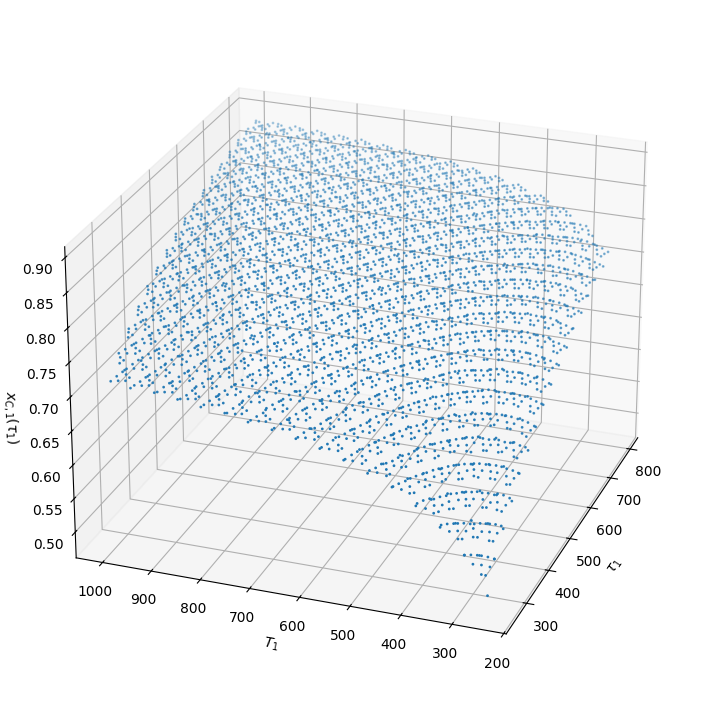

In [19]:
samOutput = np.array(samOutput)

fig = plt.figure(figsize=(14, 9))
ax = plt.axes(projection='3d')
ax.set_xlabel(r'$\tau_1$')
ax.set_ylabel(r'$T_1$')
ax.set_zlabel(r'$x_{C,1}(\tau_1)$')

ax.scatter(samInput[:, 0], samInput[:, 1], samOutput[:, 0], s=1)
ax.view_init(elev=25, azim=200)

plt.show()

We can also evaluate the derivatives of the two outputs $x_{C,1}, x_{B,2}$ with respect to any of the inputs $\tau_1,T_1,\tau_2,T_2$. The derivatives of the `FFODESLV` operations are computed by forward or adjoint sensitivity analysis (`FFODESLV.options.GRADIENT`):

In [20]:
[Row, Col, Grad] = DAG.fdiff([xC1_f, xB2_f], [tau1, T1, tau2, T2])
print("Row:", Row)
print("Col:", Col)

Grad_val = DAG.eval(Grad, inputs, nominal)
print("Grad =", Grad_val)

Row: [0, 1, 0, 1, 1, 1]
Col: [0, 0, 1, 1, 2, 3]
Grad = [0.00042421883213971154, -4.1595279123861456e-07, 8.059497490633952e-05, -7.762596582180223e-08, -1.6260202708472255e-06, -7.005240181340423e-07]
